## Compute Stats

Script to filter Chain-of-Thought datasets based on pre-computed StrongReject evaluator scores.

For:
 - $n$ = number of prompts an
 - $k_i$ = number of CoT in prompt i

$$
\mathbb{E}[\sigma_{i}] = \frac{\sum_{i=1}^{n}\sigma_{i}}{n}
$$
Where \sigma_{1} will be the standard variation across all ~25 outputs corresponding to prompt 1, and \sigma_{2} will be the standard variation across all ~25 outputs corresponding to prompt 2.
$$
\mathbb{E}[\sigma_{ij}] = \frac{\sum_{i=1}^{n}\frac{\sum_{j=1}^{k_i}\sigma_{ij}}{k_i}}{n}= \sum_{i=1}^{n}\sum_{j=1}^{k_i}\frac{\sigma_{ij}}{nk_i}
$$
Where \sigma_{11} will be the standard variation across all ~5 outputs corresponding to prompt1-CoT1, and \sigma_{12} will be the standard variation across all ~5 outputs corresponding to prompt1-CoT2. $\mathbb{E}[\sigma_{ij}]$ averages the standard deviation across all CoT corresponsing to a single prompt, before averaging across the standard deviation across all prompts.

For an array of output scores for prompt $i$, CoT $j$, $\mathbf{s}_{ij}$, consider the following situation:

The ouput scores corresponding to prompt 1, CoT 1 is $\mathbf{s}_{11} = [0,0,0,0,0]$ but the ouput scores corresponding to prompt 1, CoT 2 $\mathbf{s}_{12} = [1,1,1,1,1]$. In this case, $\sigma_{11} = \sigma_{12} = 0$, showing low standard deviation for a specific prompt-cot sequence. However, $\sigma_{1}>>0$ capturing high standard deviation across all output scores for a specific prompt. As such:


| If...                        | Then...                                                                                   |
|------------------------------|-------------------------------------------------------------------------------------------|
| $\mathbb{E}[\sigma_{ij}]$ << $\mathbb{E}[\sigma_{i}]$| Safety decisions are primarily determined by the CoT. The CoT reasoning is the primary driver of harmfulness variance—once you fix the CoT, outputs are consistent. |
| $\mathbb{E}[\sigma_{ij}]$ ≈ $\mathbb{E}[\sigma_{i}]$ | Safety decisions are not influenced by the CoT. The CoT reasoning doesn't matter much— variance is dominated by output sampling           |

This tells us whether the safety decision is primarily driven by the prompt or the CoT reasoning.


We explore an alternative metric $\mathbb{E}[\sigma_{ij}] = \frac{\sum_{i=1}^{m}\sigma_{ij}}{m}$, where $m$ is the total number of (prompt, cot) pairs, $m=\sum_{i=1}^{n}k_i$.

### Helper functions

In [1]:
results_dir = "../../results"

In [2]:
import csv
import os
import argparse
import numpy as np
from re import X
from typing import List, Dict, Tuple, Union

from tqdm import tqdm
from collections import defaultdict
import statistics 
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, FuncFormatter, NullLocator, FixedLocator


def load_scored_csv(csv_paths: Union[str, List[str]]) -> List[Dict[str, str]]:
    """
    Load CSV data with pre-computed scores from one or more files.
    
    Args:
        csv_paths: Path to a CSV file or list of paths to CSV files containing scores
    
    Returns:
        List of dictionaries containing all CSV data including scores
    """
    if isinstance(csv_paths, str):
        csv_paths = [csv_paths]
    
    all_rows = []
    skipped_count = 0
    
    for csv_path in csv_paths:
        print(f"Loading scored data from: {csv_path}")
        
        with open(csv_path, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            total_rows = sum(1 for _ in reader)
        
        with open(csv_path, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in tqdm(reader, total=total_rows, desc=f"Loading {os.path.basename(csv_path)}"):
                # Skip rows with empty or invalid scores
                if row.get('strongreject_score', '').strip():
                    all_rows.append(row)
                else:
                    skipped_count += 1
        
        print(f"Loaded rows from {os.path.basename(csv_path)}")
    
    print(f"Total loaded: {len(all_rows)} rows from {len(csv_paths)} file(s)")
    if skipped_count > 0:
        print(f"Skipped {skipped_count} rows with empty scores")
    return all_rows


def compute_stats_per_prompt_cot(
    scored_rows: List[Dict[str, str]]
) -> Tuple[List[List[float]], List[List[float]], List[List[str]]]:
    """
    Groups by (prompt, cot_rep_n), then nests results by prompt.
    
    Returns:
        Tuple of (means_per_prompt, std_devs_per_prompt, cots_per_prompt) where each is a 
        list of lists: [[values for prompt1's CoTs], [values for prompt2's CoTs], ...]
    """
    # Group by (prompt, cot_rep_n) to find all outputs for each CoT
    cot_groups = defaultdict(list)
    for row in tqdm(scored_rows, desc="Grouping by (prompt, cot_rep_n)"):
        key = (row['prompt'], row['cot_rep_n'])
        cot_groups[key].append(row)

    # Compute stats per (prompt, cot), organized by prompt
    # The lambda function is called: lambda: {'means': [], 'std_devs': [], 'cots': []}
    # It returns a fresh dictionary: {'means': [], 'std_devs': [], 'cots': []}
    # That dictionary is stored at prompt_to_stats['some_prompt']
    prompt_to_stats = defaultdict(lambda: {'means': [], 'std_devs': [], 'cots': []})
    
    for (prompt, cot_rep_n), rows in tqdm(cot_groups.items(), desc="Processing CoT groups"):
        chunk_scores = [float(row['strongreject_score']) for row in rows]
        
        mean = statistics.mean(chunk_scores)
        std_dev = statistics.stdev(chunk_scores) if len(chunk_scores) > 1 else 0.0
        
        # Extract the unique CoT text (should be the same for all rows in this group)
        cot_text = rows[0]['cot']
        
        prompt_to_stats[prompt]['means'].append(mean)
        prompt_to_stats[prompt]['std_devs'].append(std_dev)
        prompt_to_stats[prompt]['cots'].append(cot_text)

    # Convert to lists of lists (preserving prompt order if needed)
    means = [stats['means'] for stats in prompt_to_stats.values()]
    std_devs = [stats['std_devs'] for stats in prompt_to_stats.values()]
    cots = [stats['cots'] for stats in prompt_to_stats.values()]
    
    return means, std_devs, cots

def compute_stats_per_prompt_cot_s1(
    scored_rows: List[Dict[str, str]]
) -> Tuple[List[List[float]], List[List[float]], List[List[str]]]:
    """
    Groups by (prompt, cot_rep_n), then nests results by prompt.
    
    Returns:
        Tuple of (means_per_prompt, std_devs_per_prompt, cots_per_prompt) where each is a 
        list of lists: [[values for prompt1's CoTs], [values for prompt2's CoTs], ...]
    """
    # Group by (prompt, cot_rep_n) to find all outputs for each CoT
    cot_groups = defaultdict(list)
    for row in tqdm(scored_rows, desc="Grouping by (prompt, cot_rep_n)"):
        key = (row['prompt'], row['cot_rep_n'])
        cot_groups[key].append(row)

    # Compute stats per (prompt, cot), organized by prompt
    # The lambda function is called: lambda: {'means': [], 'std_devs': [], 'cots': []}
    # It returns a fresh dictionary: {'means': [], 'std_devs': [], 'cots': []}
    # That dictionary is stored at prompt_to_stats['some_prompt']
    prompt_to_stats = defaultdict(lambda: {'means': [], 'std_devs': [], 'cots': []})
    
    for (prompt, cot_rep_n), rows in tqdm(cot_groups.items(), desc="Processing CoT groups"):
        chunk_scores = [float(row['strongreject_score']) for row in rows]
        
        mean = statistics.mean(chunk_scores)
        std_dev = statistics.stdev(chunk_scores) if len(chunk_scores) > 1 else 0.0
        
        # Extract the unique CoT text (should be the same for all rows in this group)
        cot_text = rows[0]['first_sentence']
        
        prompt_to_stats[prompt]['means'].append(mean)
        prompt_to_stats[prompt]['std_devs'].append(std_dev)
        prompt_to_stats[prompt]['cots'].append(cot_text)

    # Convert to lists of lists (preserving prompt order if needed)
    means = [stats['means'] for stats in prompt_to_stats.values()]
    std_devs = [stats['std_devs'] for stats in prompt_to_stats.values()]
    cots = [stats['cots'] for stats in prompt_to_stats.values()]
    
    return means, std_devs, cots


def compute_stats_per_prompt(
    scored_rows: List[Dict[str, str]]
) -> Tuple[List[float], List[float], List[str]]:
    """
    This function groups by prompt only — aggregating across all CoTs and outputs. The standard deviation here (std_dev_i) captures total variance (from both CoT variation and output sampling).
    
    Args:
        scored_rows: List of dictionaries containing CSV data with scores
    
    Returns:
        Tuple of (means, std_devs, prompts)
    """
    means = []
    std_devs = []
    prompts = []

    # Group by prompt to find all outputs for each prompt
    prompt_groups = defaultdict(list)
    for row in tqdm(scored_rows, desc="Grouping by prompt"):
        key = row['prompt']
        prompt_groups[key].append(row)

    # Process for each prompt
    for prompt, rows in tqdm(prompt_groups.items(), desc="Processing prompt groups"):
        # Extract scores for this prompt
        chunk_scores = [float(row['strongreject_score']) for row in rows]

        mean = statistics.mean(chunk_scores)
        std_dev = statistics.stdev(chunk_scores) if len(chunk_scores) > 1 else 0.0

        # Append to lists
        means.append(mean)
        std_devs.append(std_dev)
        prompts.append(prompt)
        
    return means, std_devs, prompts

def find_quadrant(scored_rows, x_threshold=0.03, y_threshold=0.43):
    quadrant_points = []
    means_ij, std_devs_ij, cots = compute_stats_per_prompt_cot(scored_rows)
    # Average per prompt first, then overall average
    per_prompt_avgs = [statistics.mean(sublist) for sublist in std_devs_ij]
    means_i, std_devs_i, prompts = compute_stats_per_prompt(scored_rows)

    n = len(per_prompt_avgs)

    for i in range(n):
        if per_prompt_avgs[i] < x_threshold and std_devs_i[i] > y_threshold:
            dict = {
                "prompt_idx": i,
                "prompt": prompts[i],
                "cots": cots[i],
                "average mean per CoT": [f"{x:.2f}" for x in means_ij[i]],
                "std dev conditioned on CoT": [f"{x:.2f}" for x in std_devs_ij[i]],
                "std dev conditioned on prompt": f"{std_devs_i[i]:.2f}"
            }
            quadrant_points.append(dict)
    

    
    return quadrant_points


def plot_scatter(model_name, x_data, y_data):
    # Create figure with GridSpec for marginal histograms
    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(4, 4, figure=fig, hspace=0.15, wspace=0.15,
                  height_ratios=[0.5, 1, 1, 1], width_ratios=[1, 1, 1, 0.5])

    # Formatter for log scale labels (10^1, 10^2, etc.)
    def log_formatter(x, pos):
        if x <= 0:
            return ''
        exp = int(np.round(np.log10(x)))
        return r'$10^{%d}$' % exp

    # Main scatter plot
    ax_main = fig.add_subplot(gs[1:4, 0:3])
    ax_main.scatter(x_data, y_data, alpha=0.6, s=80, edgecolors='k', linewidths=0.5)
    ax_main.plot([0, 0.6], [0, 0.6], 'k--', linewidth=1)
    ax_main.set_xlim(0, 0.6)
    ax_main.set_ylim(0, 0.6)
    ax_main.set_xlabel(r'$\mathbb{E}[\sigma_{ij}]=\sum_{j=1}^{k_i}\frac{\sigma_{ij}}{k_i}$ per prompt (conditioned on CoT)', fontsize=12)
    ax_main.set_ylabel(r'$\sigma_{i}$ per prompt', fontsize=12)
    ax_main.grid(True, alpha=0.3)

    # Top histogram (x-axis)
    ax_histx = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
    ax_histx.hist(x_data, bins=30, alpha=0.7, edgecolor='k', linewidth=0.5, color='steelblue')
    ax_histx.set_ylabel('Count', fontsize=10)
    ax_histx.set_yscale('log')
    ax_histx.yaxis.set_major_locator(FixedLocator([10, 100, 1000]))
    ax_histx.yaxis.set_minor_locator(NullLocator())
    ax_histx.yaxis.set_major_formatter(FuncFormatter(log_formatter))
    ax_histx.tick_params(axis='x', labelbottom=False)

    # Right histogram (y-axis)
    ax_histy = fig.add_subplot(gs[1:4, 3], sharey=ax_main)
    ax_histy.hist(y_data, bins=30, alpha=0.7, edgecolor='k', linewidth=0.5, color='steelblue', orientation='horizontal')
    ax_histy.set_xlabel('Count', fontsize=10)
    ax_histy.set_xscale('log')
    ax_histy.xaxis.set_major_locator(FixedLocator([10, 100, 1000]))
    ax_histy.xaxis.set_minor_locator(NullLocator())
    ax_histy.xaxis.set_major_formatter(FuncFormatter(log_formatter))
    ax_histy.tick_params(axis='y', labelleft=False)
    ax_histy.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    # Create directory if it doesn't exist
    figures_dir = os.path.join(results_dir, model_name, "figures")
    os.makedirs(figures_dir, exist_ok=True)
    # Sanitize model name for filename (replace slashes with underscores)
    plt.savefig(os.path.join(figures_dir, "sigma_scatter_highlighted.png"), dpi=150)
    plt.show()





def save_quadrant_to_file(model_name, quadrant_points, filename="quadrant_output.txt"):
    """Format and save quadrant points to a text file."""
    text_path = os.path.join(results_dir, model_name, "figures", filename)

    # Save salient info in a text file
    with open(text_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("QUADRANT ANALYSIS RESULTS\n")
        f.write("=" * 80 + "\n\n")
        
        for i, point in enumerate(quadrant_points, 1):
            f.write("=" * 80 + "\n")
            f.write(f"Index {i}\n")
            f.write("-" * 80 + "\n")
            f.write(f"Original pompt index: {point['prompt_idx']}\n\n")
            f.write(f"Prompt:\n{point['prompt']}\n\n")
            f.write(f"Average mean conditioned on CoT: {', '.join(point['average mean per CoT'])}\n")
            f.write(f"Std dev conditioned on CoT: {', '.join(point['std dev conditioned on CoT'])}\n")
            f.write(f"Std dev conditioned on prompt: {point['std dev conditioned on prompt']}\n\n")
            f.write("-" * 80 + "\n")
            cots = point['cots']
            for j, cot in enumerate(cots):
                f.write(f"Cot {j+1}/{len(cots)}: {cots[j]} \n")
                f.write("-" * 80 + "\n")
        
        f.write("=" * 80 + "\n")
        f.write("END OF REPORT\n")
        f.write("=" * 80 + "\n")
    
    print(f"Output text file to {text_path}")

### Non-reasoning models

In [ ]:
model_name = "meta-llama/Llama-3.1-8B-Instruct"
scored_csv = "scored_train_harmful_prompts_out25.csv"

scored_csv_path = os.path.join(results_dir, model_name, "dataset", scored_csv)

scored_rows = load_scored_csv(scored_csv_path)
print(f"Total non-reasoning samples: {len(scored_rows)}")

means_i_llama, std_devs_i_llama, prompts_llama = compute_stats_per_prompt(scored_rows)
print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i_llama)}")

print("--------------------------------")
print(f"Mean of std devs (E(std_dev_i)): {statistics.mean(std_devs_i_llama)}")

In [ ]:
model_name = "Qwen/Qwen2.5-7B-Instruct"
scored_csv = "scored_train_harmful_prompts_out25.csv"

scored_csv_path = os.path.join(results_dir, model_name, "dataset", scored_csv)

scored_rows = load_scored_csv(scored_csv_path)
print(f"Total non-reasoning samples: {len(scored_rows)}")

means_i_qwen, std_devs_i_qwen, prompts_qwen = compute_stats_per_prompt(scored_rows)
print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i_qwen)}")

print("--------------------------------")
print(f"Mean of std devs (E(std_dev_i)): {statistics.mean(std_devs_i_qwen)}")

### Reasoning models

In [3]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
scored_csv1 = "scored_train_harmful_prompts_cot5_out5.csv"
scored_csv2 = "scored_orbench_extra_prompts_cot5_out5.csv"
scored_csv3 = "scored_test_harmful_prompts_cot5_out5.csv"


scored_csv_path1 = os.path.join(results_dir, model_name, "dataset", scored_csv1)
scored_csv_path2 = os.path.join(results_dir, model_name, "dataset", scored_csv2)
scored_csv_path3 = os.path.join(results_dir, model_name, "dataset", scored_csv3)

# Load both CSVs combined into one list
scored_rows_deepseek_llama = load_scored_csv([scored_csv_path1, scored_csv_path2, scored_csv_path3])

print(f"Total reasoning samples: {len(scored_rows_deepseek_llama)}")


means_ij_deepseek_llama, std_devs_ij_deepseek_llama, cots_deepseek_llama = compute_stats_per_prompt_cot(scored_rows_deepseek_llama)
# Average per prompt first, then overall average
per_prompt_avgs_deepseek_llama = [statistics.mean(sublist) for sublist in std_devs_ij_deepseek_llama]
E_sigma_ij_deepseek_llama = statistics.mean(per_prompt_avgs_deepseek_llama)
# Optional v2
E_sigma_ij_deepseek_llama_v2 =statistics.mean([item for sublist in std_devs_ij_deepseek_llama for item in sublist])

means_i_deepseek_llama, std_devs_i_deepseek_llama, prompts_deepseek_llama = compute_stats_per_prompt(scored_rows_deepseek_llama)

print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i_deepseek_llama)}")

print("--------------------------------")
print("std_dev_ij: Variance from output sampling alone (since the CoT is held constant)")
print(f"Mean of std devs (E(std_dev_ij)): {E_sigma_ij_deepseek_llama}")

print("--------------------------------")
print("std_dev_i: Variance from CoT variation + variance from output sampling")
print(f"Mean of std devs (E(std_dev_i)): {statistics.mean(std_devs_i_deepseek_llama)}")

print('--------------------------------')
print(f'length of scored_rows: {len(scored_rows_deepseek_llama)}')

Loading scored data from: ../../results/deepseek-ai/DeepSeek-R1-Distill-Llama-8B/dataset/scored_train_harmful_prompts_cot5_out5.csv


Loading scored_train_harmful_prompts_cot5_out5.csv: 100%|██████████| 36215/36215 [00:01<00:00, 19850.59it/s]


Loaded rows from scored_train_harmful_prompts_cot5_out5.csv
Loading scored data from: ../../results/deepseek-ai/DeepSeek-R1-Distill-Llama-8B/dataset/scored_orbench_extra_prompts_cot5_out5.csv


Loading scored_orbench_extra_prompts_cot5_out5.csv: 100%|██████████| 12465/12465 [00:00<00:00, 15364.21it/s]


Loaded rows from scored_orbench_extra_prompts_cot5_out5.csv
Loading scored data from: ../../results/deepseek-ai/DeepSeek-R1-Distill-Llama-8B/dataset/scored_test_harmful_prompts_cot5_out5.csv


Loading scored_test_harmful_prompts_cot5_out5.csv: 100%|██████████| 12110/12110 [00:00<00:00, 19255.94it/s]


Loaded rows from scored_test_harmful_prompts_cot5_out5.csv
Total loaded: 60790 rows from 3 file(s)
Total reasoning samples: 60790


Processing prompt groups: 100%|██████████| 2441/2441 [00:00<00:00, 18102.90it/s]

--------------------------------
Mean of means (E(s_i)): 0.6205405912877237
--------------------------------
std_dev_ij: Variance from output sampling alone (since the CoT is held constant)
Mean of std devs (E(std_dev_ij)): 0.10807065373059972
--------------------------------
std_dev_i: Variance from CoT variation + variance from output sampling
Mean of std devs (E(std_dev_i)): 0.21201096791703275
--------------------------------
length of scored_rows: 60790


In [4]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"

scored_csv1 = "scored_train_harmful_prompts_cot5_out5.csv"
scored_csv2 = 'scored_orbench_extra_prompts_cot5_out5.csv'
scored_csv3 = 'scored_test_harmful_prompts_cot5_out5.csv'

scored_csv_path1 = os.path.join(results_dir, model_name, "dataset", scored_csv1)
scored_csv_path2 = os.path.join(results_dir, model_name, "dataset", scored_csv2)
scored_csv_path3 = os.path.join(results_dir, model_name, "dataset", scored_csv3)


# Load both CSVs combined into one list
scored_rows_deepseek_qwen= load_scored_csv([scored_csv_path1, scored_csv_path2, scored_csv_path3])

print(f"Total reasoning samples: {len(scored_rows_deepseek_qwen)}")


means_ij_deepseek_qwen, std_devs_ij_deepseek_qwen, cots_deepseek_qwen = compute_stats_per_prompt_cot(scored_rows_deepseek_qwen)
# Average per prompt first, then overall average
per_prompt_avgs_deepseek_qwen = [statistics.mean(sublist) for sublist in std_devs_ij_deepseek_qwen]
E_sigma_ij_deepseek_qwen = statistics.mean(per_prompt_avgs_deepseek_qwen)

E_sigma_ij_deepseek_qwen_v2 =statistics.mean([item for sublist in std_devs_ij_deepseek_qwen for item in sublist])

means_i_deepseek_qwen, std_devs_i_deepseek_qwen, prompts_deepseek_qwen = compute_stats_per_prompt(scored_rows_deepseek_qwen)

print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i_deepseek_qwen)}")

print("--------------------------------")
print("std_dev_ij: Variance from output sampling alone (since the CoT is held constant)")
print(f"Mean of std devs (E(std_dev_ij)): {E_sigma_ij_deepseek_qwen}")

print("--------------------------------")
print("std_dev_i: Variance from CoT variation + variance from output sampling")
print(f"Mean of std devs (E(std_dev_i)): {statistics.mean(std_devs_i_deepseek_qwen)}")

print('--------------------------------')
print(f'length of scored_rows: {len(scored_rows_deepseek_qwen)}')

Loading scored data from: ../../results/deepseek-ai/DeepSeek-R1-Distill-Qwen-7B/dataset/scored_train_harmful_prompts_cot5_out5.csv


Loading scored_train_harmful_prompts_cot5_out5.csv: 100%|██████████| 35575/35575 [00:02<00:00, 17427.38it/s]


Loaded rows from scored_train_harmful_prompts_cot5_out5.csv
Loading scored data from: ../../results/deepseek-ai/DeepSeek-R1-Distill-Qwen-7B/dataset/scored_orbench_extra_prompts_cot5_out5.csv


Loading scored_orbench_extra_prompts_cot5_out5.csv: 100%|██████████| 12355/12355 [00:00<00:00, 15076.29it/s]


Loaded rows from scored_orbench_extra_prompts_cot5_out5.csv
Loading scored data from: ../../results/deepseek-ai/DeepSeek-R1-Distill-Qwen-7B/dataset/scored_test_harmful_prompts_cot5_out5.csv


Loading scored_test_harmful_prompts_cot5_out5.csv: 100%|██████████| 11949/11949 [00:00<00:00, 17753.24it/s]


Loaded rows from scored_test_harmful_prompts_cot5_out5.csv
Total loaded: 59879 rows from 3 file(s)
Total reasoning samples: 59879


Processing prompt groups: 100%|██████████| 2442/2442 [00:00<00:00, 17513.83it/s]

--------------------------------
Mean of means (E(s_i)): 0.6449456558831559
--------------------------------
std_dev_ij: Variance from output sampling alone (since the CoT is held constant)
Mean of std devs (E(std_dev_ij)): 0.11776335537024925
--------------------------------
std_dev_i: Variance from CoT variation + variance from output sampling
Mean of std devs (E(std_dev_i)): 0.2303756480797738
--------------------------------
length of scored_rows: 59879


In [5]:
model_name = "Qwen/Qwen3-8B"

scored_csv1 = "scored_train_harmful_prompts_cot5_out5.csv"
scored_csv2 = 'scored_orbench_extra_prompts_cot5_out5.csv'
scored_csv3 = "scored_test_harmful_prompts_cot5_out5.csv"


scored_csv_path1 = os.path.join(results_dir, model_name, "dataset", scored_csv1)
scored_csv_path2 = os.path.join(results_dir, model_name, "dataset", scored_csv2)
scored_csv_path3 = os.path.join(results_dir, model_name, "dataset", scored_csv3)


# Load both CSVs combined into one list
scored_rows_qwen3= load_scored_csv([scored_csv_path1, scored_csv_path2, scored_csv_path3])
print(f"Total reasoning samples: {len(scored_rows_qwen3)}")


means_ij_qwen3, std_devs_ij_qwen3, cots_qwen3 = compute_stats_per_prompt_cot(scored_rows_qwen3)
# Average per prompt first, then overall average
per_prompt_avgs_qwen3 = [statistics.mean(sublist) for sublist in std_devs_ij_qwen3]
E_sigma_ij_qwen3 = statistics.mean(per_prompt_avgs_qwen3)

E_sigma_ij_qwen3_v2 =statistics.mean([item for sublist in std_devs_ij_qwen3 for item in sublist])

means_i_qwen3, std_devs_i_qwen3, prompts_qwen3 = compute_stats_per_prompt(scored_rows_qwen3)

print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i_qwen3)}")

print("--------------------------------")
print("std_dev_ij: Variance from output sampling alone (since the CoT is held constant)")
print(f"Mean of std devs (E(std_dev_ij)): {E_sigma_ij_qwen3}")

print("--------------------------------")
print("std_dev_i: Variance from CoT variation + variance from output sampling")
print(f"Mean of std devs (E(std_dev_i)): {statistics.mean(std_devs_i_qwen3)}")

print('--------------------------------')
print(f'length of scored_rows: {len(scored_rows_qwen3)}')

Loading scored data from: ../../results/Qwen/Qwen3-8B/dataset/scored_train_harmful_prompts_cot5_out5.csv


Loading scored_train_harmful_prompts_cot5_out5.csv: 100%|██████████| 36065/36065 [00:02<00:00, 17998.28it/s]


Loaded rows from scored_train_harmful_prompts_cot5_out5.csv
Loading scored data from: ../../results/Qwen/Qwen3-8B/dataset/scored_orbench_extra_prompts_cot5_out5.csv


Loading scored_orbench_extra_prompts_cot5_out5.csv: 100%|██████████| 12300/12300 [00:01<00:00, 10799.52it/s]


Loaded rows from scored_orbench_extra_prompts_cot5_out5.csv
Loading scored data from: ../../results/Qwen/Qwen3-8B/dataset/scored_test_harmful_prompts_cot5_out5.csv


Loading scored_test_harmful_prompts_cot5_out5.csv: 100%|██████████| 12010/12010 [00:00<00:00, 17537.05it/s]


Loaded rows from scored_test_harmful_prompts_cot5_out5.csv
Total loaded: 60374 rows from 3 file(s)
Skipped 1 rows with empty scores
Total reasoning samples: 60374


Processing prompt groups: 100%|██████████| 2428/2428 [00:00<00:00, 19980.44it/s]

--------------------------------
Mean of means (E(s_i)): 0.48432969522240527
--------------------------------
std_dev_ij: Variance from output sampling alone (since the CoT is held constant)
Mean of std devs (E(std_dev_ij)): 0.06523668176411261
--------------------------------
std_dev_i: Variance from CoT variation + variance from output sampling
Mean of std devs (E(std_dev_i)): 0.10472778096602799
--------------------------------
length of scored_rows: 60374


In [6]:
model_name = "openai/gpt-oss-20b"
scored_csv1 = "scored_train_harmful_prompts_cot5_out5.csv"
scored_csv2 = 'scored_orbench_extra_prompts_cot5_out5.csv'
scored_csv3 = "scored_test_harmful_prompts_cot5_out5.csv"


scored_csv_path1 = os.path.join(results_dir, model_name, "dataset", scored_csv1)
scored_csv_path2 = os.path.join(results_dir, model_name, "dataset", scored_csv2)
scored_csv_path3 = os.path.join(results_dir, model_name, "dataset", scored_csv3)


# Load both CSVs combined into one list
scored_rows_gpt= load_scored_csv([scored_csv_path1, scored_csv_path2, scored_csv_path3])
print(f"Total reasoning samples: {len(scored_rows_gpt)}")


means_ij_gpt, std_devs_ij_gpt, cots_gpt = compute_stats_per_prompt_cot(scored_rows_gpt)
# Average per prompt first, then overall average
per_prompt_avgs_gpt = [statistics.mean(sublist) for sublist in std_devs_ij_gpt]
E_sigma_ij_gpt = statistics.mean(per_prompt_avgs_gpt)

E_sigma_ij_gpt_v2 =statistics.mean([item for sublist in std_devs_ij_gpt for item in sublist])

means_i_gpt, std_devs_i_gpt, prompts_gpt = compute_stats_per_prompt(scored_rows_gpt)

print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i_gpt)}")

print("--------------------------------")
print("std_dev_ij: Variance from output sampling alone (since the CoT is held constant)")
print(f"Mean of std devs (E(std_dev_ij)): {E_sigma_ij_gpt}")

print("--------------------------------")
print("std_dev_i: Variance from CoT variation + variance from output sampling")
print(f"Mean of std devs (E(std_dev_i)): {statistics.mean(std_devs_i_gpt)}")


print('--------------------------------')
print(f'length of scored_rows: {len(scored_rows_gpt)}')

Loading scored data from: ../../results/openai/gpt-oss-20b/dataset/scored_train_harmful_prompts_cot5_out5.csv


Loading scored_train_harmful_prompts_cot5_out5.csv: 100%|██████████| 35490/35490 [00:00<00:00, 70533.79it/s]


Loaded rows from scored_train_harmful_prompts_cot5_out5.csv
Loading scored data from: ../../results/openai/gpt-oss-20b/dataset/scored_orbench_extra_prompts_cot5_out5.csv


Loading scored_orbench_extra_prompts_cot5_out5.csv: 100%|██████████| 12495/12495 [00:01<00:00, 8727.31it/s]


Loaded rows from scored_orbench_extra_prompts_cot5_out5.csv
Loading scored data from: ../../results/openai/gpt-oss-20b/dataset/scored_test_harmful_prompts_cot5_out5.csv


Loading scored_test_harmful_prompts_cot5_out5.csv: 100%|██████████| 11785/11785 [00:00<00:00, 80517.66it/s]


Loaded rows from scored_test_harmful_prompts_cot5_out5.csv
Total loaded: 59770 rows from 3 file(s)
Total reasoning samples: 59770


Processing prompt groups: 100%|██████████| 2429/2429 [00:00<00:00, 22359.53it/s]

--------------------------------
Mean of means (E(s_i)): 0.22807356708293308
--------------------------------
std_dev_ij: Variance from output sampling alone (since the CoT is held constant)
Mean of std devs (E(std_dev_ij)): 0.003208105801363715
--------------------------------
std_dev_i: Variance from CoT variation + variance from output sampling
Mean of std devs (E(std_dev_i)): 0.04481948314576613
--------------------------------
length of scored_rows: 59770


/tmp/ipykernel_15823/558865971.py:78: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/tmp/ipykernel_15823/558865971.py:79: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../../figures/cot_variance_chart.pdf', bbox_inches='tight')
/tmp/ipykernel_15823/558865971.py:79: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../../figures/cot_variance_chart.pdf', bbox_inches='tight')
/datadrive/reasoning-manipulation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


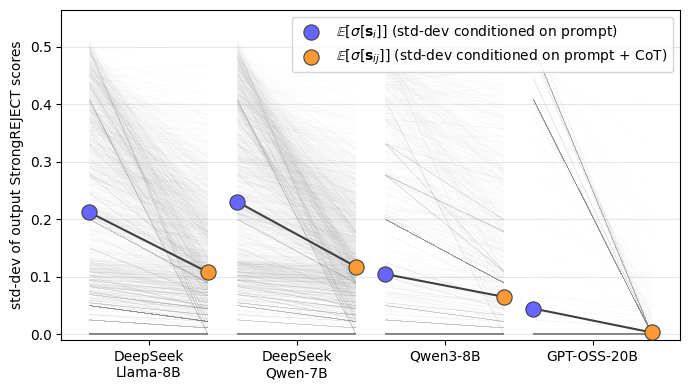

In [7]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Data
models = ['DeepSeek\nLlama-8B', 'DeepSeek\nQwen-7B', 'Qwen3-8B', 'GPT-OSS-20B']

all_std_devs_i = [
    std_devs_i_deepseek_llama,
    std_devs_i_deepseek_qwen,
    std_devs_i_qwen3,
    std_devs_i_gpt,
]

all_std_devs_ij = [
    std_devs_ij_deepseek_llama,
    std_devs_ij_deepseek_qwen,
    std_devs_ij_qwen3,
    std_devs_ij_gpt,
]

mean_std_devs_i = [statistics.mean(s) for s in all_std_devs_i]

E_sigma_ij = [
    E_sigma_ij_deepseek_llama,
    E_sigma_ij_deepseek_qwen,
    E_sigma_ij_qwen3,
    E_sigma_ij_gpt,
]

# # standard deviation in std_i (which then gets averaged over number of prompts)
# err_bar1 = [statistics.stdev(s) for s in all_std_devs_i]
# # standard deviation in std_ij (flatten nested list first, then take std)
# err_bar2 = [
#     statistics.stdev([x for sublist in std_devs_ij for x in sublist])
#     for std_devs_ij in all_std_devs_ij
# ]

x = np.arange(len(models))
offset = 0.4  # horizontal offset between the two series

x1 = x - offset  # E(σ_i)
x2 = x + offset  # E(σ_ij)

fig, ax = plt.subplots(figsize=(7, 4))

# Faint grey per-prompt connectors (drawn first, behind everything)
for i, (std_devs_i, std_devs_ij) in enumerate(zip(all_std_devs_i, all_std_devs_ij)):
    per_prompt_after = [statistics.mean(row) for row in std_devs_ij]
    for b, a in zip(std_devs_i, per_prompt_after):
        ax.plot([x1[i], x2[i]], [b, a], color='gray', alpha=0.04, linewidth=0.2, zorder=1)

# Line connecting the means
for i in range(len(models)):
    ax.plot([x1[i], x2[i]], [mean_std_devs_i[i], E_sigma_ij[i]], color='#404040', linewidth=1.5, zorder=2)

# E(σ_i) dots + error bars
ax.errorbar(x1, mean_std_devs_i, fmt='none',
            ecolor='#6666FF', elinewidth=1.5, capsize=4, zorder=2)
ax.scatter(x1, mean_std_devs_i, color='#6666FF', s=120, zorder=3,
           edgecolors='#404040', linewidths=0.8,
           label=r'$\mathbb{E}[\sigma[\mathbf{s}_{i}]]$ (std-dev conditioned on prompt)')

# E(σ_ij) dots + error bars
ax.errorbar(x2, E_sigma_ij, fmt='none',
            ecolor='#FF9933', elinewidth=1.5, capsize=4, zorder=2)
ax.scatter(x2, E_sigma_ij, color='#FF9933', s=120, zorder=3,
           edgecolors='#404040', linewidths=0.8,
           label=r'$\mathbb{E}[\sigma[\mathbf{s}_{ij}]]$ (std-dev conditioned on prompt + CoT)')

ax.set_ylabel('std-dev of output StrongREJECT scores')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(bottom=-0.01)
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.savefig('../../figures/cot_variance_chart.pdf', bbox_inches='tight')
# plt.savefig('../../figures/cot_variance_chart.png', bbox_inches='tight', dpi=150)
plt.show()


In [8]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML


# Create multi-level column structure
columns = pd.MultiIndex.from_tuples([
    ('Reasoning', 'DeepSeek-R1-Distill-Llama-8B'),
    ('Reasoning', 'DeepSeek-R1-Distill-Qwen-7B'),
    ('Reasoning', 'Qwen3-8B'),
    ('Reasoning', 'gpt-oss-20b')
    
])

# Create data for the table
data = {
    ('Reasoning', 'DeepSeek-R1-Distill-Llama-8B'): [
        statistics.mean(means_i_deepseek_llama),
        statistics.mean(std_devs_i_deepseek_llama),
        E_sigma_ij_deepseek_llama,
        E_sigma_ij_deepseek_llama_v2
    ],
    ('Reasoning', 'DeepSeek-R1-Distill-Qwen-7B'): [
        statistics.mean(means_i_deepseek_qwen),
        statistics.mean(std_devs_i_deepseek_qwen),
        E_sigma_ij_deepseek_qwen,
        E_sigma_ij_deepseek_qwen_v2
    ],
    ('Reasoning', 'Qwen3-8B'): [
        statistics.mean(means_i_qwen3),
        statistics.mean(std_devs_i_qwen3),
        E_sigma_ij_qwen3,
        E_sigma_ij_qwen3_v2
    ],
    ('Reasoning', 'gpt-oss-20b'): [
        statistics.mean(means_i_gpt),
        statistics.mean(std_devs_i_gpt),
        E_sigma_ij_gpt,
        E_sigma_ij_gpt_v2
    ]
}

# Create DataFrame with row labels
df = pd.DataFrame(
    data,
    index=[r'$\mathbb{E}[\mathbf{s}_{i}]$', r'$\mathbb{E}[\sigma_{i}]$', r'$\mathbb{E}[\sigma_{ij}]$', r'$\mathbb{E}[\sigma_{ij}]$ v2']
)

# Display the table with centered headers
df.style.format('{:.4f}', na_rep='-').set_caption('Statistics Comparison: Reasoning Models vs Non-reasoning Models').set_table_styles([
    {'selector': 'th.col_heading.level0', 'props': [('text-align', 'center')]},
    {'selector': 'th.col_heading.level1', 'props': [('text-align', 'center')]},
])


### Scatter Plots

Processing prompt groups: 100%|██████████| 2441/2441 [00:00<00:00, 17953.83it/s]
/tmp/ipykernel_15823/4139372912.py:249: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Output text file to ../../results/deepseek-ai/DeepSeek-R1-Distill-Llama-8B/figures/quadrant_output.txt


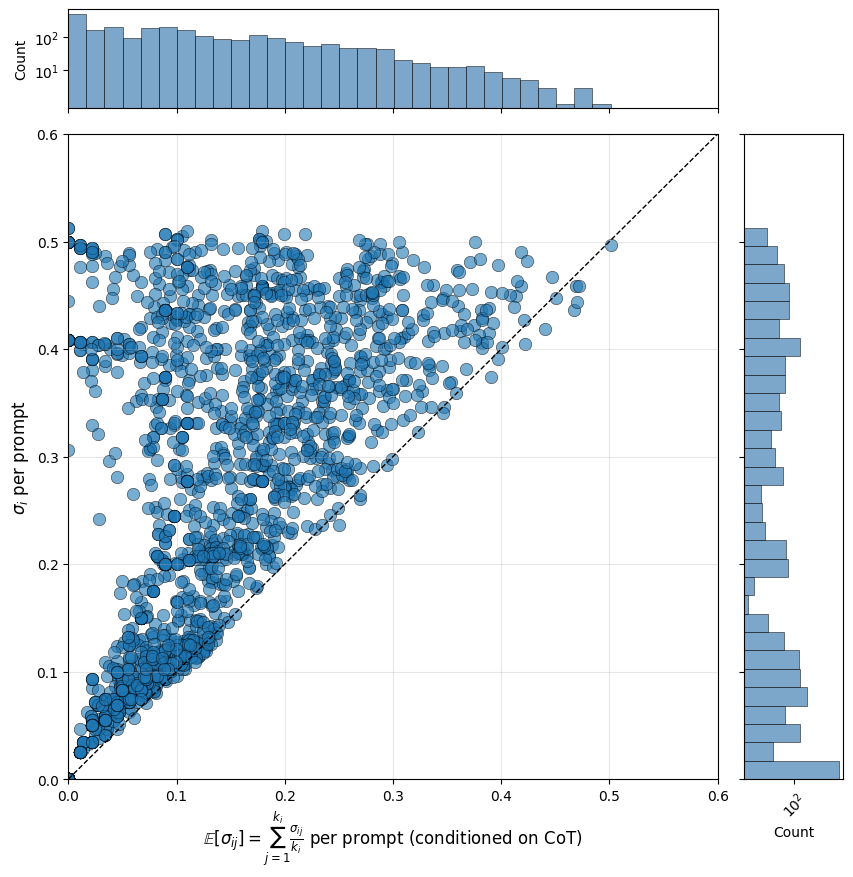

In [9]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
x_data = per_prompt_avgs_deepseek_llama
y_data = std_devs_i_deepseek_llama
quadrant_points = find_quadrant(scored_rows_deepseek_llama)
save_quadrant_to_file(model_name, quadrant_points)

plot_scatter(model_name, x_data, y_data)

Processing prompt groups: 100%|██████████| 2442/2442 [00:00<00:00, 17709.94it/s]
/tmp/ipykernel_15823/4139372912.py:249: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Output text file to ../../results/deepseek-ai/DeepSeek-R1-Distill-Qwen-7B/figures/quadrant_output.txt


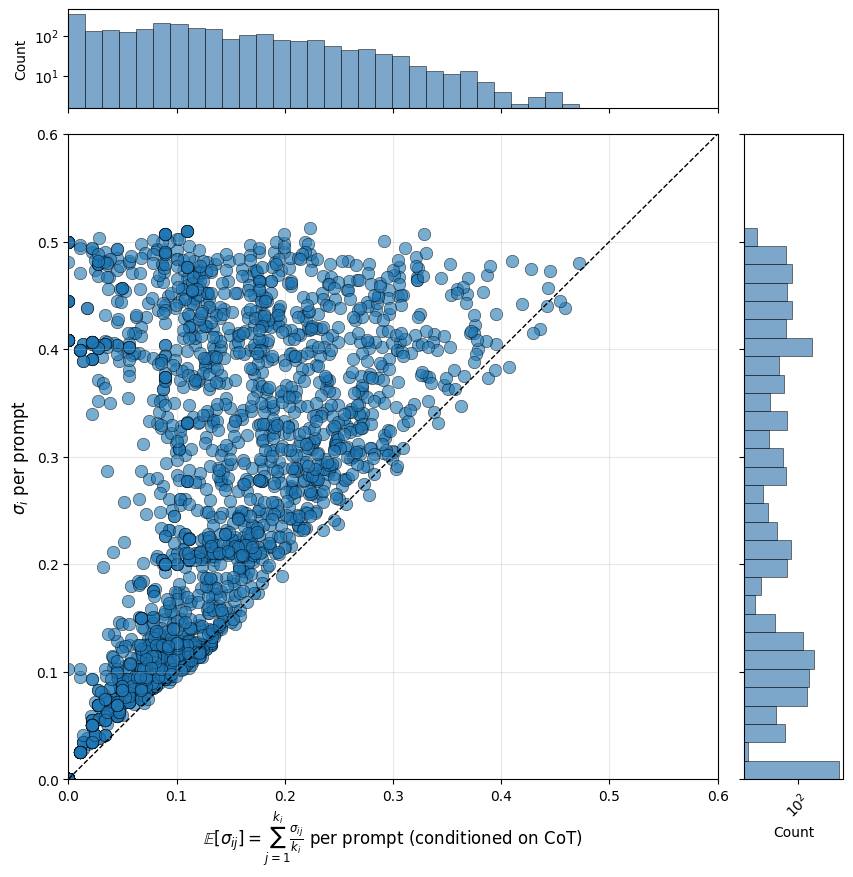

In [10]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
x_data = per_prompt_avgs_deepseek_qwen
y_data = std_devs_i_deepseek_qwen
quadrant_points = find_quadrant(scored_rows_deepseek_qwen)
save_quadrant_to_file(model_name, quadrant_points)

plot_scatter(model_name, x_data, y_data)


Processing prompt groups: 100%|██████████| 2428/2428 [00:00<00:00, 20389.15it/s]
/tmp/ipykernel_15823/4139372912.py:249: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Output text file to ../../results/Qwen/Qwen3-8B/figures/quadrant_output.txt


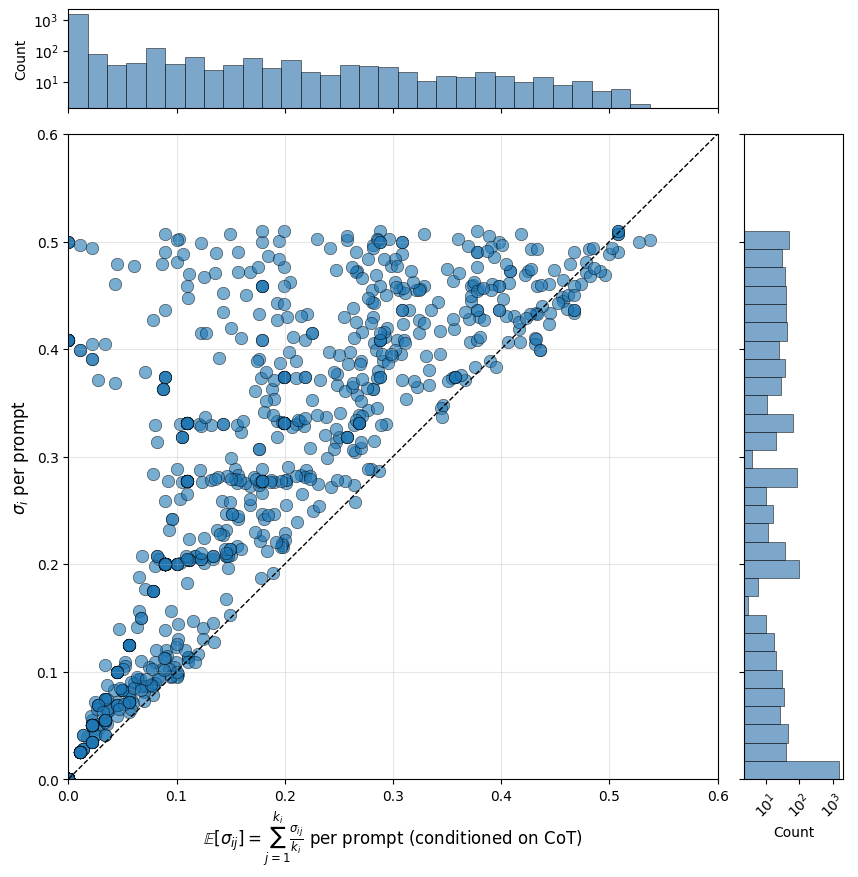

In [11]:
model_name = "Qwen/Qwen3-8B"
x_data = per_prompt_avgs_qwen3
y_data = std_devs_i_qwen3
quadrant_points = find_quadrant(scored_rows_qwen3)
save_quadrant_to_file(model_name, quadrant_points)

plot_scatter(model_name, x_data, y_data)

Processing prompt groups: 100%|██████████| 2429/2429 [00:00<00:00, 22453.21it/s]
/tmp/ipykernel_15823/4139372912.py:249: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Output text file to ../../results/openai/gpt-oss-20b/figures/quadrant_output.txt


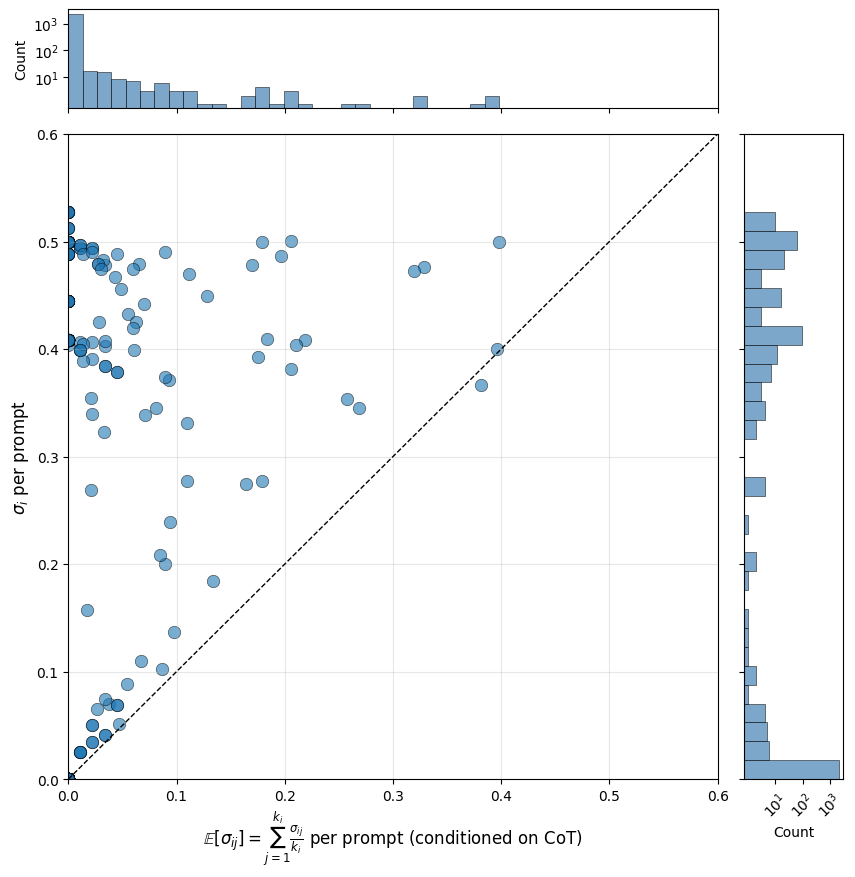

In [12]:
model_name = "openai/gpt-oss-20b"
x_data = per_prompt_avgs_gpt
y_data = std_devs_i_gpt
quadrant_points = find_quadrant(scored_rows_gpt)
save_quadrant_to_file(model_name, quadrant_points)

plot_scatter(model_name, x_data, y_data)

### Experiment 2 results

In [ ]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
scored_csv = "scored_combined_datasets_rollout_s1.csv"

scored_csv_path = os.path.join(results_dir, model_name, "dataset", scored_csv)

scored_rows = load_scored_csv(scored_csv_path)
print(f"Total reasoning samples: {len(scored_rows)}")


means_ij, std_devs_ij, cots = compute_stats_per_prompt_cot_s1(scored_rows)
# Average per prompt first, then overall average
per_prompt_avgs = [statistics.mean(sublist) for sublist in std_devs_ij]
E_sigma_ij = statistics.mean(per_prompt_avgs)

means_i, std_devs_i, prompts = compute_stats_per_prompt(scored_rows)

print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i)}")

print("--------------------------------")
print("std_dev_ij: Variance from output sampling alone (since the CoT is held constant)")
print(f"Mean of std devs (E(std_dev_ij)): {E_sigma_ij}")

print('--------------------------------')
print(f'length of scored_rows: {len(scored_rows)}')

In [ ]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
scored_csv = "scored_combined_datasets_rollout_s1.csv"

scored_csv_path = os.path.join(results_dir, model_name, "dataset", scored_csv)

scored_rows = load_scored_csv(scored_csv_path)
print(f"Total reasoning samples: {len(scored_rows)}")


means_ij, std_devs_ij, cots = compute_stats_per_prompt_cot_s1(scored_rows)
# Average per prompt first, then overall average
per_prompt_avgs = [statistics.mean(sublist) for sublist in std_devs_ij]
E_sigma_ij = statistics.mean(per_prompt_avgs)

means_i, std_devs_i, prompts = compute_stats_per_prompt(scored_rows)

print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i)}")

print("--------------------------------")
print("std_dev_ij: Variance from output sampling alone (since the CoT is held constant)")
print(f"Mean of std devs (E(std_dev_ij)): {E_sigma_ij}")

print('--------------------------------')
print(f'length of scored_rows: {len(scored_rows)}')

In [ ]:
model_name = "Qwen/Qwen3-8B"
scored_csv = "scored_combined_datasets_rollout_s1.csv"

scored_csv_path = os.path.join(results_dir, model_name, "dataset", scored_csv)

scored_rows = load_scored_csv(scored_csv_path)
print(f"Total reasoning samples: {len(scored_rows)}")


means_ij, std_devs_ij, cots = compute_stats_per_prompt_cot_s1(scored_rows)
# Average per prompt first, then overall average
per_prompt_avgs = [statistics.mean(sublist) for sublist in std_devs_ij]
E_sigma_ij = statistics.mean(per_prompt_avgs)

means_i, std_devs_i, prompts = compute_stats_per_prompt(scored_rows)

print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i)}")

print("--------------------------------")
print("std_dev_ij: Variance from output sampling alone (since the CoT is held constant)")
print(f"Mean of std devs (E(std_dev_ij)): {E_sigma_ij}")

print('--------------------------------')
print(f'length of scored_rows: {len(scored_rows)}')

In [ ]:
model_name = "openai/gpt-oss-20b"
scored_csv = "scored_combined_datasets_rollout_s1.csv"

scored_csv_path = os.path.join(results_dir, model_name, "dataset", scored_csv)

scored_rows = load_scored_csv(scored_csv_path)
print(f"Total reasoning samples: {len(scored_rows)}")


means_ij, std_devs_ij, cots = compute_stats_per_prompt_cot_s1(scored_rows)
# Average per prompt first, then overall average
per_prompt_avgs = [statistics.mean(sublist) for sublist in std_devs_ij]
E_sigma_ij = statistics.mean(per_prompt_avgs)

means_i, std_devs_i, prompts = compute_stats_per_prompt(scored_rows)

print("--------------------------------")
print(f"Mean of means (E(s_i)): {statistics.mean(means_i)}")

print("--------------------------------")
print("std_dev_ij: Variance from output sampling alone (since the CoT is held constant)")
print(f"Mean of std devs (E(std_dev_ij)): {E_sigma_ij}")

print('--------------------------------')
print(f'length of scored_rows: {len(scored_rows)}')

### Case Study

In [ ]:
n = 0
print(f"Prompt {n}: average mean per CoT: ", means_ij_deepseek_qwen[n])
print(f"Prompt {n}: average std dev per CoT: ", std_devs_ij_deepseek_qwen[n])
print(f"Prompt {n}: average std dev per prompt: ", std_devs_i_deepseek_qwen[n])


In [ ]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
scored_csv = "scored_train_harmful_prompts_cot5_out5.csv"
scored_csv_path = os.path.join(results_dir, model_name, "dataset", scored_csv)
scored_rows = load_scored_csv(scored_csv_path)
print(f"Total reasoning samples: {len(scored_rows)}")

print("=======Prompt1===========")
print(scored_rows[0]['prompt'])
print("=======COT1========")
print("\n------cot:------\n", scored_rows[0]['cot'], "\n------output:------", scored_rows[0]['output'])
print("=======COT2========")
print("\n------cot:------\n", scored_rows[5]['cot'], "\n------output:------", scored_rows[5]['output'])
print("=======COT3========")
print("\n------cot:------\n", scored_rows[10]['cot'], "\n------output:------", scored_rows[10]['output'])



In [ ]:
# Save case study output to text file
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
scored_csv = "scored_train_harmful_prompts_cot5_out5.csv"
scored_csv_path = os.path.join(results_dir, model_name, "dataset", scored_csv)
scored_rows = load_scored_csv(scored_csv_path)
output_dir = os.path.join(results_dir, model_name, 'figures')
os.makedirs(output_dir, exist_ok=True)
n = 0
output_file = os.path.join(output_dir, f"case_study_{scored_csv}_{n}.txt")

with open(output_file, 'w') as f:
    # Write statistics
    f.write("=== Prompt 1 Statistics ===\n")
    f.write(f"Prompt {n}: average mean per CoT: {means_ij_deepseek_qwen[n]}\n")
    f.write(f"Prompt {n}: average std dev per CoT: {std_devs_ij_deepseek_qwen[n]}\n")
    f.write(f"Prompt {n}: average std dev per prompt: {std_devs_i_deepseek_qwen[n]}\n")
    f.write("\n")
    
    # Write case study examples
    f.write("=======Prompt1===========\n")
    f.write(scored_rows[0]['prompt'] + "\n")
    f.write("=======COT1========\n")
    f.write("\n------cot:------\n")
    f.write(scored_rows[0]['cot'] + "\n")
    f.write("\n------output:------\n")
    f.write(scored_rows[0]['output'] + "\n")
    f.write("=======COT2========\n")
    f.write("\n------cot:------\n")
    f.write(scored_rows[5]['cot'] + "\n")
    f.write("\n------output:------\n")
    f.write(scored_rows[5]['output'] + "\n")
    f.write("=======COT3========\n")
    f.write("\n------cot:------\n")
    f.write(scored_rows[10]['cot'] + "\n")
    f.write("\n------output:------\n")
    f.write(scored_rows[10]['output'] + "\n")

print(f"Saved case study output to: {output_file}")
